# Questão 1
Vantagens e desvantagens do uso de grafos no TensorFlow.

In [ ]:

# Vantagens:
# - Permite otimização dos cálculos (paralelização e distribuição).
# - Facilita o deploy em diferentes dispositivos (CPU, GPU, TPU).
# - TensorBoard pode ser utilizado para visualização dos grafos.
# - Melhor performance em grandes modelos.

# Desvantagens:
# - Maior complexidade para entender e depurar.
# - Menor flexibilidade em tempo de execução (no modo gráfico, especialmente nas versões 1.x).
# - Necessita definir todo o grafo antes da execução (em TF 1.x).


# Questão 2
Verificação se `a.eval(session=sess)` é equivalente a `sess.run(a)`.

In [1]:

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Cria o grafo
a = tf.constant(5.0)

with tf.Session() as sess:
    val1 = a.eval(session=sess)
    val2 = sess.run(a)
    print(f'Usando eval: {val1}, Usando sess.run: {val2}')

# Ambos são equivalentes, retornam o mesmo valor.


Instructions for updating:
non-resource variables are not supported in the long term


Usando eval: 5.0, Usando sess.run: 5.0


# Questão 3
Comparação entre múltiplas avaliações usando eval vs sess.run.

In [2]:

b = tf.constant(10.0)

with tf.Session() as sess:
    val1_a, val1_b = a.eval(session=sess), b.eval(session=sess)
    val2_a, val2_b = sess.run([a, b])
    print(f'Eval: {val1_a}, {val1_b} | Sess.run: {val2_a}, {val2_b}')

# sess.run([a, b]) é mais eficiente pois executa ambos de uma só vez.


Eval: 5.0, 10.0 | Sess.run: 5.0, 10.0


# Questão 4
Execução de dois grafos na mesma sessão.

In [3]:

# Sim, desde que os grafos sejam unidos no momento da definição.
# Caso sejam grafos completamente separados, é necessário usar sessões diferentes.

g1 = tf.Graph()
g2 = tf.Graph()

with g1.as_default():
    a = tf.constant(3)

with g2.as_default():
    b = tf.constant(4)

with tf.Session(graph=g1) as sess1, tf.Session(graph=g2) as sess2:
    print(sess1.run(a))
    print(sess2.run(b))


3
4


# Questão 5
Quando variáveis são inicializadas e destruídas.

In [4]:

# Inicialização: quando executamos `sess.run(tf.global_variables_initializer())`.
# Destruição: quando a sessão é encerrada (`sess.close()` ou saindo do bloco `with`).

x = tf.Variable(3)

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    print(sess.run(x))


3


# Questão 6
Diferença entre placeholder e variável.

In [5]:

# Placeholder: entrada de dados, fornecida no momento da execução.
# Variável: guarda estado, seus valores podem ser atualizados e persistem entre execuções.

ph = tf.placeholder(dtype=tf.float32, shape=(None,))
var = tf.Variable(initial_value=5.0)

# Se executar uma operação que depende do placeholder sem fornecer valor, dá erro.


# Questão 7
O que acontece ao não fornecer valor para placeholder.

In [6]:

# Se uma operação depende do placeholder e não é fornecido valor -> ERRO.
# Se a operação não depende do placeholder, ela executa normalmente.

ph = tf.placeholder(dtype=tf.float32, shape=(None,))
const = tf.constant(10.0)

with tf.Session() as sess:
    print(sess.run(const))  # Funciona
    # print(sess.run(ph))   # ERRO: Placeholder sem valor


10.0


# Questão 8
Alterando valores de variáveis com assign.

In [7]:

x = tf.Variable(5.0)
new_value = tf.placeholder(tf.float32)

assign_op = x.assign(new_value)

with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    print('Valor inicial:', sess.run(x))

    sess.run(assign_op, feed_dict={new_value: 20.0})
    print('Novo valor:', sess.run(x))


Valor inicial: 5.0
Novo valor: 20.0


# Questão 9
Regressão logística com gradiente descendente em mini-batches usando TensorFlow.

Epoch 0: Val Loss = 1.3092516660690308
Epoch 50: Val Loss = 0.2296258509159088
Epoch 100: Val Loss = 0.19105340540409088
Epoch 150: Val Loss = 0.1682198941707611
Epoch 200: Val Loss = 0.15150971710681915
Epoch 250: Val Loss = 0.13826976716518402
Epoch 300: Val Loss = 0.12733952701091766
Epoch 350: Val Loss = 0.11808640509843826
Epoch 400: Val Loss = 0.11011970788240433
Epoch 450: Val Loss = 0.10317438840866089
Precisão: 0.9801980198019802


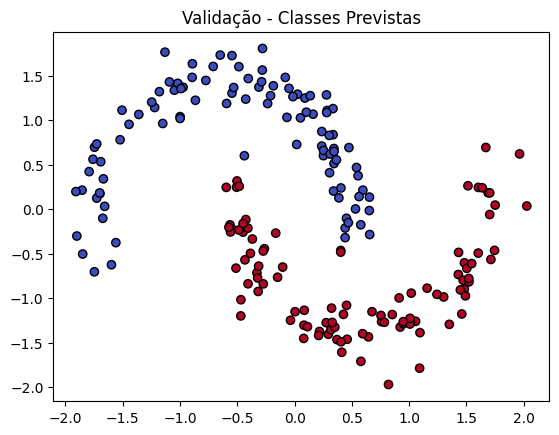

In [8]:

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
import numpy as np
import matplotlib.pyplot as plt
import os

# Gerar dados
N = 1000
X, y = make_moons(N, noise=0.1, random_state=42)

# Separar em treino e validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Adicionar features polinomiais
def add_features(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.c_[x1, x2, x1**2, x2**2, x1**3, x2**3]

X_train_poly = add_features(X_train)
X_val_poly = add_features(X_val)

# Hiperparâmetros
n_inputs = X_train_poly.shape[1]
learning_rate = 0.01
n_epochs = 500
batch_size = 50
n_batches = len(X_train_poly) // batch_size

# Construção do grafo
X = tf.placeholder(tf.float32, shape=(None, n_inputs), name="X")
y = tf.placeholder(tf.float32, shape=(None, 1), name="y")

theta = tf.Variable(tf.random_uniform([n_inputs, 1], -1.0, 1.0), name="theta")
logits = tf.matmul(X, theta)
y_proba = tf.sigmoid(logits)

loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=logits))

optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate)
training_op = optimizer.minimize(loss)

init = tf.global_variables_initializer()
saver = tf.train.Saver()

# TensorBoard
logdir = "logs"
loss_summary = tf.summary.scalar('LOSS', loss)
file_writer = tf.summary.FileWriter(logdir, tf.get_default_graph())

# Treinamento
checkpoint_path = "model_checkpoint.ckpt"

with tf.Session() as sess:
    sess.run(init)

    for epoch in range(n_epochs):
        indices = np.random.permutation(len(X_train_poly))
        X_batches = np.array_split(X_train_poly[indices], n_batches)
        y_batches = np.array_split(y_train.reshape(-1, 1)[indices], n_batches)

        for X_batch, y_batch in zip(X_batches, y_batches):
            sess.run(training_op, feed_dict={X: X_batch, y: y_batch})

        if epoch % 50 == 0:
            loss_val, summary = sess.run([loss, loss_summary], feed_dict={X: X_val_poly, y: y_val.reshape(-1, 1)})
            file_writer.add_summary(summary, epoch)
            print(f"Epoch {epoch}: Val Loss = {loss_val}")
            saver.save(sess, checkpoint_path)

    saver.save(sess, "final_model.ckpt")

    # Avaliação
    y_val_proba = sess.run(y_proba, feed_dict={X: X_val_poly})
    y_val_pred = (y_val_proba >= 0.5).astype(np.int32)
    print("Precisão:", precision_score(y_val, y_val_pred))

    # Plotar
    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val_pred.reshape(-1), cmap="coolwarm", edgecolor="k")
    plt.title("Validação - Classes Previstas")
    plt.show()


# Questão 10
Modificação para gradiente descendente estocástico (SGD).

Epoch 0: Val Loss = 0.18904359638690948
Epoch 50: Val Loss = 0.02848057821393013
Epoch 100: Val Loss = 0.016883548349142075
Epoch 150: Val Loss = 0.012424107640981674
Epoch 200: Val Loss = 0.010001369751989841
Epoch 250: Val Loss = 0.008454730734229088
Epoch 300: Val Loss = 0.007369662635028362
Epoch 350: Val Loss = 0.006560764741152525
Epoch 400: Val Loss = 0.005931015592068434
Epoch 450: Val Loss = 0.00542423827573657
Precisão com SGD: 1.0


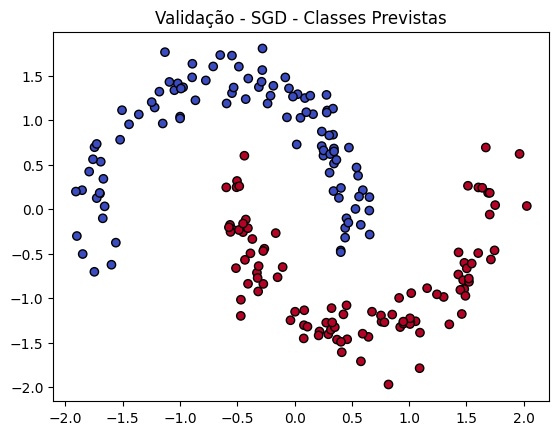

In [9]:

# A diferença para SGD é usar batch_size=1 (um exemplo por vez).
batch_size = 1
n_batches = len(X_train_poly) // batch_size

with tf.Session() as sess:
    sess.run(init)

    for epoch in range(n_epochs):
        indices = np.random.permutation(len(X_train_poly))
        X_batches = np.array_split(X_train_poly[indices], n_batches)
        y_batches = np.array_split(y_train.reshape(-1, 1)[indices], n_batches)

        for X_batch, y_batch in zip(X_batches, y_batches):
            sess.run(training_op, feed_dict={X: X_batch, y: y_batch})

        if epoch % 50 == 0:
            loss_val = sess.run(loss, feed_dict={X: X_val_poly, y: y_val.reshape(-1, 1)})
            print(f"Epoch {epoch}: Val Loss = {loss_val}")

    saver.save(sess, "final_model_SGD.ckpt")

    y_val_proba = sess.run(y_proba, feed_dict={X: X_val_poly})
    y_val_pred = (y_val_proba >= 0.5).astype(np.int32)
    print("Precisão com SGD:", precision_score(y_val, y_val_pred))

    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val_pred.reshape(-1), cmap="coolwarm", edgecolor="k")
    plt.title("Validação - SGD - Classes Previstas")
    plt.show()
